In [9]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

from fizinfo import *

In [10]:
auto_raw = GPS_to_num_kinem('auto-Posta-Egyetem.csv', orig='first')
auto = num_kinem_smooth_r(auto_raw, 0.1, lam=50, err_report=True)
#auto.plot_rcomp()

Adatsor pontosság: RMS=3.854; MAX=5.110
Eltérés          : RMS=1.840; MAX=6.117


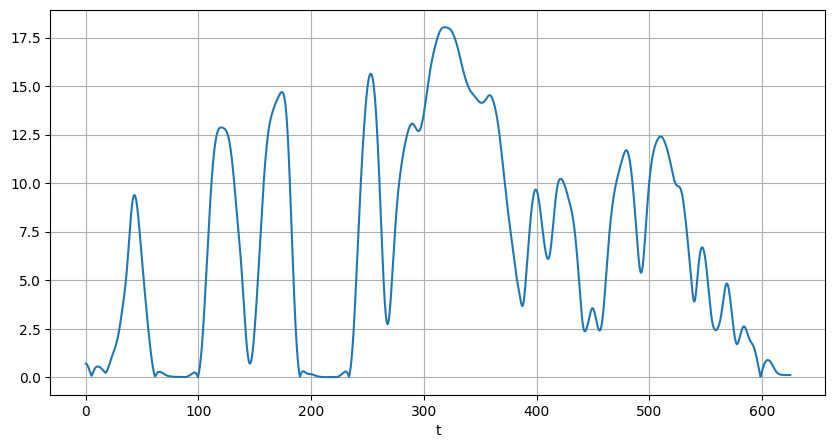

In [11]:
# a) Ábrázolja a auto sebességének nagyságát az idő függvényében! 2p
auto.full_kinem_calc()

fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(auto.t,auto.v_abs)
ax1.set_xlabel('t')

ax1.grid()

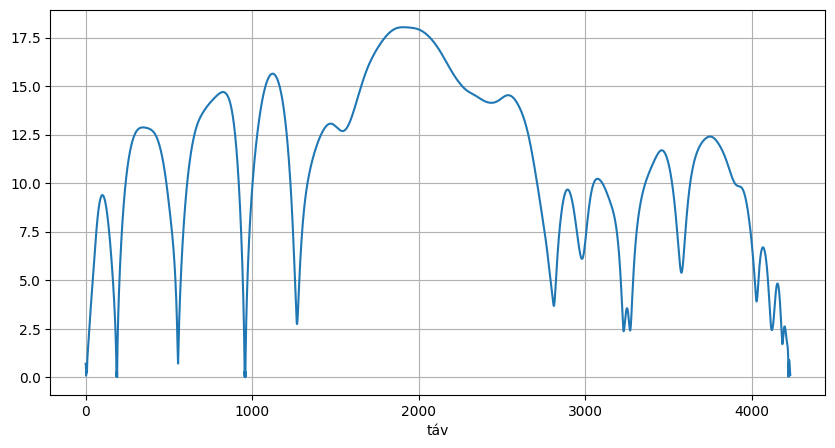

In [12]:
# a) Ábrázolja a auto sebességének nagyságát az útvonalhossz függvényében! 2p

fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(auto.pathlength,auto.v_abs)
ax1.set_xlabel('táv')

ax1.grid()

In [16]:
# b) A menetidő és az út hány százalékát töltötte az autó nagyjából egyenletes sebességű haladással, 
# azaz amikor mozgásirányú gyorsulásának abszolút értéke kisebb volt, mint 0.1 m/s^2? (4 p)

egyenletes_hatar = 0.1 # m/s

dt = auto.t[1:] - auto.t[:-1] # lépésköz, azaz mennyi idő telt el két egymást követő mérés között
dr = auto.pathlength[1:] - auto.pathlength[:-1] # lépésköz, azaz mennyi idő telt el két egymást követő mérés között

# a lassulást (negatív értékeket) is kiszűrjük! - Erős fékezést nem számítjuk bele
egyenletes_haladasok = np.abs(auto.a_t_abs[:-1]) < egyenletes_hatar

ossz_egyenletes_ido = dt[egyenletes_haladasok].sum() # csak a True helyeken lévő dt-k összege
ossz_egyenletes_tav = dr[egyenletes_haladasok].sum() # csak a True helyeken lévő dt-k összege

print(f'A auto az ido {ossz_egyenletes_ido / auto.t[-1] * 100:.2f}% ban ment egyenletes sebessggel.')
print(f'A auto az út {ossz_egyenletes_tav / auto.pathlength[-1] * 100:.2f}% ban ment egyenletes sebessggel.')



A auto az ido 30.47% ban ment egyenletes sebessggel.
A auto az út 22.24% ban ment egyenletes sebessggel.


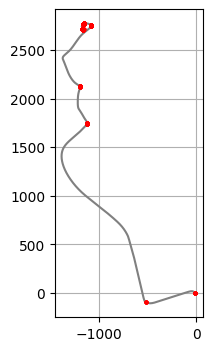

In [18]:
# c) Készítsen ábrát, melyen az autó pályája szürke, és rajta pirossal az erős kanyarodási részek vannak bejelölve, 
# azaz azok, ahol a pálya görbületi sugara 20 m-nél kisebb, de a sebesség nagysága 2 m/s-nál nagyobb volt. (4 p)

# Rinv a görbületi sugár reciproka (1/R). Ha R < 20, akkor 1/R > 1/20. Ezzel elkerüljük a nullával osztást az egyeneseknél.
kanyar = (auto.v_abs > 2.0) & (auto.Rinv > 1/20) # bool tömb maszk az erős kanyarokra

fig = plt.figure(figsize=(14, 4))  
ax1 = plt.subplot(111)

ax1.plot(auto.r[:, 0], auto.r[:, 1], color="grey") # a teljes pályagörbe (összes x és y koordináta)

# a 'kanyar' maszk alapján csak a True helyeken lévő x és y pontokat rajzoljuk pirossal a szürke vonal fölé (zorder=3)
ax1.scatter(auto.r[kanyar, 0], auto.r[kanyar, 1], color='red', s=4, zorder=3)                    

ax1.set_aspect(aspect='equal') # ne torzuljon a térkép (1m az X-en = 1m az Y-on)
ax1.grid()

In [19]:
# d) Mennyi volt a menetidő és mennyi lett volna,
# ha az autónak sosem kellett volna 10 km/h-nál jobban lelassítania?

sebesseg_hatar = 10 / 3.6   # 10 km/h -> m/s átváltás

dt = auto.t[1:] - auto.t[:-1]                          # lépésenkénti időközök
dr = auto.pathlength[1:] - auto.pathlength[:-1]         # lépésenkénti megtett út

v_eredeti = auto.v_abs[:-1]                             # eredeti sebesség minden lépésben

# ha v_eredeti < 10 km/h, akkor helyette 10 km/h-t használunk (mintha nem lassult volna le)
v_korrigalt = np.maximum(v_eredeti, sebesseg_hatar)

# hipotetikus időköz: ugyanakkora utat nagyobb sebességgel → kevesebb idő (dt = dr / v)
dt_korrigalt = dr / v_korrigalt

print(f"Az eredeti menetidő:     {dt.sum():.2f} s")
print(f"A hipotetikus menetidő:  {dt_korrigalt.sum():.2f} s")

Az eredeti menetidő:     624.90 s
A hipotetikus menetidő:  475.76 s
